In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset:

df=pd.read_csv("C:\\Users\\Athira\\Downloads\\minihomeprices.csv")
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      6 non-null      int64  
 1   bedrooms  5 non-null      float64
 2   age       6 non-null      int64  
 3   price     6 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 324.0 bytes


In [4]:
df.describe()

,area,bedrooms,age,price
count,6.000000,5.00000,6.000000,6.000000
mean,3416.666667,4.20000,16.500000,648333.333333
std,587.934237,1.30384,8.288546,109117.673484
min,2600.000000,3.00000,8.000000,550000.000000
25%,3050.000000,3.00000,9.750000,572500.000000
50%,3400.000000,4.00000,16.500000,602500.000000
75%,3900.000000,5.00000,19.500000,722500.000000
max,4100.000000,6.00000,30.000000,810000.000000


In [5]:
df.isnull()

,area,bedrooms,age,price
0,False,False,False,False
1,False,False,False,False
2,False,True,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False


In [6]:
df.isnull().sum()

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [7]:
#fill null value of bedroom with its mean value:

df['bedrooms']=df['bedrooms'].fillna(df['bedrooms'].mean())
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.2,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


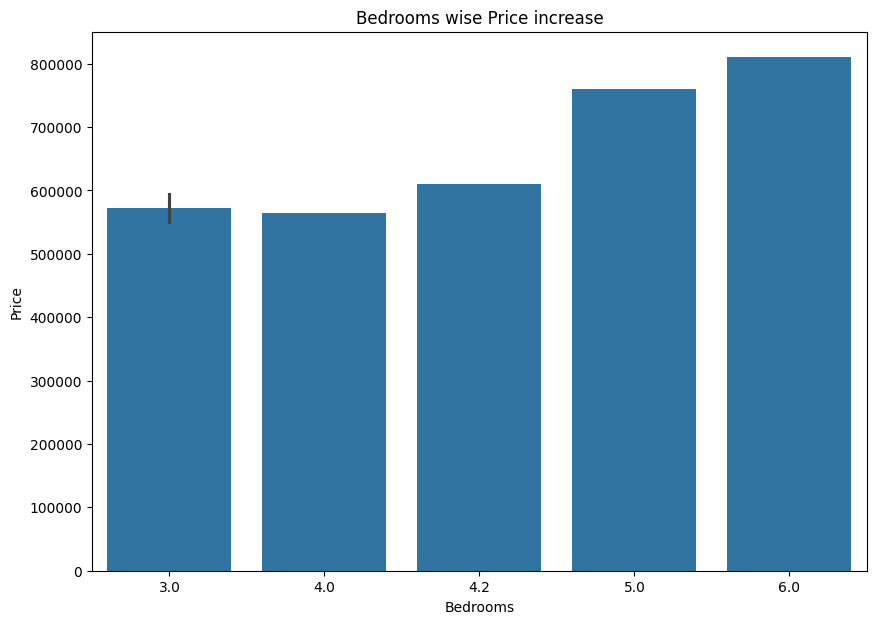

In [8]:
# DATA VISUALIZATION

#bar plot

plt.figure(figsize=(10,7))
plt.title("Bedrooms wise Price increase")

sns.barplot(x="bedrooms",y="price",data=df)

plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

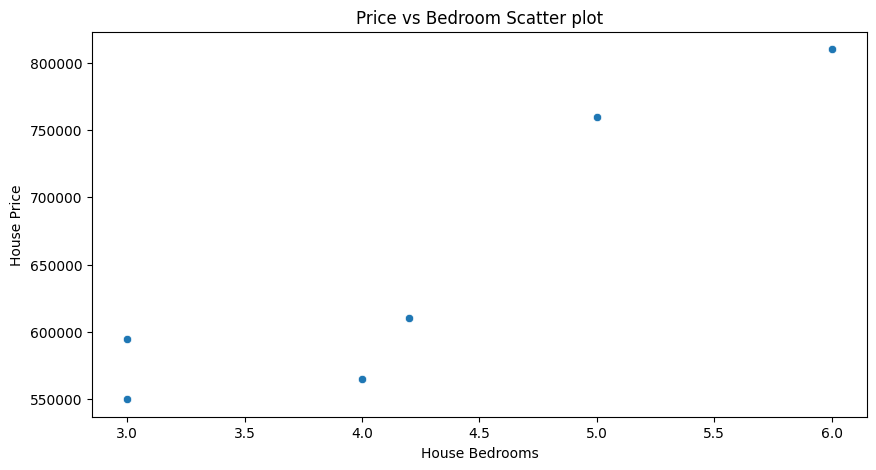

In [9]:
# Scatter plot
plt.figure(figsize=(10, 5))

sns.scatterplot(x='bedrooms', y='price',data=df)
plt.title("Price vs Bedroom Scatter plot")

plt.xlabel("House Bedrooms")
plt.ylabel('House Price')
plt.show()

<Figure size 1000x700 with 0 Axes>

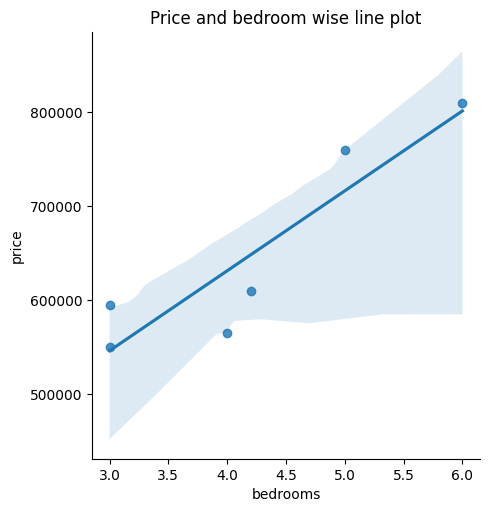

In [10]:
plt.figure(figsize=(10, 7))

sns.lmplot(x="bedrooms", y="price", data=df);
plt.title("Price and bedroom wise line plot")
plt.show()

In [11]:
#LINEAR REGRESSION MODEL

from sklearn.linear_model import LinearRegression

In [12]:
ld=LinearRegression()

In [13]:
# set independent variables and dependent variable y

y=df["price"]
X=df.drop(["price"],axis=1)

In [14]:
y

0    550000
1    565000
2    610000
3    595000
4    760000
5    810000
Name: price, dtype: int64

In [15]:
X

,area,bedrooms,age
0,2600,3.0,20
1,3000,4.0,15
2,3200,4.2,18
3,3600,3.0,30
4,4000,5.0,8
5,4100,6.0,8


In [16]:
#change bedrooms datatype float into int:

df['bedrooms']=df['bedrooms'].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   area      6 non-null      int64
 1   bedrooms  6 non-null      int64
 2   age       6 non-null      int64
 3   price     6 non-null      int64
dtypes: int64(4)
memory usage: 324.0 bytes


In [17]:
# FITTING THE MODEL:

ld.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
#value of coefficient m        'y=mx+c'
ld.coef_

array([  116.66950551, 18756.28806982, -3675.75111708])

In [19]:
#value of intercept c
ld.intercept_

np.float64(231586.0063940914)

In [20]:
#customize prediction of price
ld.predict([[6000,5,3]])

C:\Users\Athira\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1014357.22642613])

In [21]:
ld.predict([[10000,8,5]])

C:\Users\Athira\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1529952.61042422])

In [22]:
ld.predict([[9000,2,1]])

C:\Users\Athira\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1315448.38096789])

In [23]:
predicted_price = ld.predict([[3000, 4, 15]])

price = round(predicted_price[0])

print(price)

601483


C:\Users\Athira\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
import pickle

pickle.dump(ld, open("model.pkl", "wb"))